# Particle Collisions and Emergent Boltzmann-Like Mixing

A gas can be modeled as particles moving freely between elastic collisions.
Even simple local collision rules produce global mixing and statistical regularization.

We simulate 2D hard-disc particles with reflective boundaries and pairwise elastic swaps along collision frames.

A gas-like macroscopic distribution can emerge from deterministic microscopic collisions. Equal-mass elastic impacts preserve total kinetic energy and momentum along the contact normal, while wall reflections preserve speed. The simulation checks overlap, displacement scale, and speed conservation before exposing the motion through optional playback.


## Environment and Notation

We model a 2D gas in a unit square domain $\Omega=[0,1]^2$ with $k$ particles.
Each particle has position $x_i^t\in\mathbb{R}^2$ and velocity $v_i^t\in\mathbb{R}^2$ at discrete time $t$.

The update is split into two stages:

$$
\text{free flight: } x_i^{t+1}=x_i^t+v_i^t,
$$

followed by boundary reflection and pairwise collision handling.

The implementation uses complex numbers $x+iy$ for compact vectorized code, while the mechanics remain standard 2D vector dynamics.


In [1]:
import os
import os
import os
import os
import os
import os
import os
import os
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.collections import PatchCollection
from ipywidgets import IntSlider, Play, HBox, jslink, interactive_output
from IPython.display import display

plt.rcParams["figure.dpi"] = 120
rng = np.random.default_rng(3)

# Keep False in interactive use to avoid duplicate static figure.
STATIC_SNAPSHOT = os.environ.get("NBEXECUTE") == "1"


## Initialization: Controlled Density and Speed Scale

We initialize particles in a central region to avoid immediate wall-dominated behavior.
This makes the first phase of the dynamics easier to interpret.

Initial velocity directions are sampled uniformly from random Gaussian directions, and speed magnitudes are randomized in a controlled interval:

$$
v_i^0 = s_i \frac{u_i}{\|u_i\|}, \qquad s_i \sim \mathcal{U}(s_{\min}, s_{\max}).
$$

This preserves smooth motion while avoiding an overly uniform, artificial flow.


In [2]:
k = 60
radius = 0.015

def sample_non_overlapping_positions(k, radius, rng, lo=0.28, hi=0.72, padding=1.03):
    x = np.empty(k, dtype=np.complex128)
    min_dist = 2.0 * radius * padding
    i, trials, max_trials = 0, 0, 300000
    while i < k and trials < max_trials:
        cand = rng.uniform(lo, hi) + 1j * rng.uniform(lo, hi)
        trials += 1
        if i == 0 or np.all(np.abs(cand - x[:i]) >= min_dist):
            x[i] = cand
            i += 1
    if i < k:
        raise RuntimeError("Could not place all particles without overlap.")
    return x

# Initialize particles near the center with non-overlapping disks.
x = sample_non_overlapping_positions(k, radius, rng)
# Randomize direction and speed magnitude for each particle while keeping per-step motion smooth.
u = rng.standard_normal(k) + 1j * rng.standard_normal(k)
u /= np.abs(u) + 1e-12
speed = rng.uniform(1.2e-4, 3.0e-4, k)
v = speed * u

colors = plt.cm.turbo(np.linspace(0.04, 0.96, k))


## Elastic Dynamics: Walls and Binary Collisions

### Boundary reflection
At walls, we apply specular reflection:

$$
v' = v - 2\langle v,n\rangle n,
$$

where $n$ is the outward wall normal.

### Pairwise collision rule
A collision is detected from center distance and relative approach:

$$
d_{ab}=\|x_b-x_a\|<2r,\qquad (v_a-v_b)\cdot n_{ab}<0,
$$

where $n_{ab}=\frac{x_b-x_a}{\|x_b-x_a\|}$.
For equal masses, we update only the normal component:

$$
v_a' = v_a - \big((v_a-v_b)\cdot n_{ab}\big)n_{ab},\qquad
v_b' = v_b + \big((v_a-v_b)\cdot n_{ab}\big)n_{ab}.
$$

A small positional correction is also applied to remove overlap and keep the disk radius constraint consistent.

This equal-mass elastic rule preserves momentum and kinetic energy along the interaction axis.


In [3]:
def step_particles(x, v, radius):
    x = x + v
    # Mirror reflections at walls (less sticking than hard clipping).
    xr = np.real(x)
    yr = np.imag(x)

    left = xr < radius
    xr[left] = 2 * radius - xr[left]
    v[left] = -np.real(v[left]) + 1j * np.imag(v[left])
    right = xr > 1 - radius
    xr[right] = 2 * (1 - radius) - xr[right]
    v[right] = -np.real(v[right]) + 1j * np.imag(v[right])

    bottom = yr < radius
    yr[bottom] = 2 * radius - yr[bottom]
    v[bottom] = np.real(v[bottom]) - 1j * np.imag(v[bottom])
    top = yr > 1 - radius
    yr[top] = 2 * (1 - radius) - yr[top]
    v[top] = np.real(v[top]) - 1j * np.imag(v[top])

    x = xr + 1j * yr

    A, B = np.triu_indices(len(x), k=1)
    for _ in range(3):
        D = np.abs(x[:, None] - x[None, :])
        pairs = np.where((D[A, B] < 2 * radius) & (D[A, B] > 1e-12))[0]
        if len(pairs) == 0:
            break
        for idx in pairs:
            a, b = A[idx], B[idx]
            dx = x[b] - x[a]
            dist = np.abs(dx)
            if dist <= 1e-12:
                continue
            n = dx / dist
            rel_n = np.real((v[a] - v[b]) * np.conj(n))
            if rel_n < 0.0:
                # Equal-mass elastic impulse along contact normal.
                v[a] = v[a] - rel_n * n
                v[b] = v[b] + rel_n * n
            # Resolve overlap geometrically to prevent persistent interpenetration.
            overlap = 2 * radius - dist
            if overlap > 0.0:
                corr = 0.5 * overlap * n
                x[a] -= corr
                x[b] += corr
        # Keep corrected positions inside domain after collision response.
        xr = np.clip(np.real(x), radius, 1 - radius)
        yr = np.clip(np.imag(x), radius, 1 - radius)
        x = xr + 1j * yr
    return x, v


## Time Discretization, Sampling, and Speed Diagnostics

We simulate many fine time steps but keep one displayed frame every `every` updates.
Displayed motion therefore depends on velocity scale and on frame subsampling.

To measure dynamics quantitatively, we track:

$$
\bar s_t = \frac{1}{k}\sum_{i=1}^k \|v_i^t\|
$$

(mean per-step speed), and

$$
\bar d_f = \frac{1}{k}\sum_{i=1}^k \|x_i^{f}-x_i^{f-1}\|
$$

(mean displacement between displayed frames).

These diagnostics make it easy to tune smoothness in a principled way.


Stored frames: 800
Mean displacement per simulation step: 0.00019953500013487492
Mean displacement per displayed frame: 0.0005711006147498026
Displayed-frame displacement p95: 0.0005890299033356557
Max pair overlap over run: 5.850761860276554e-05


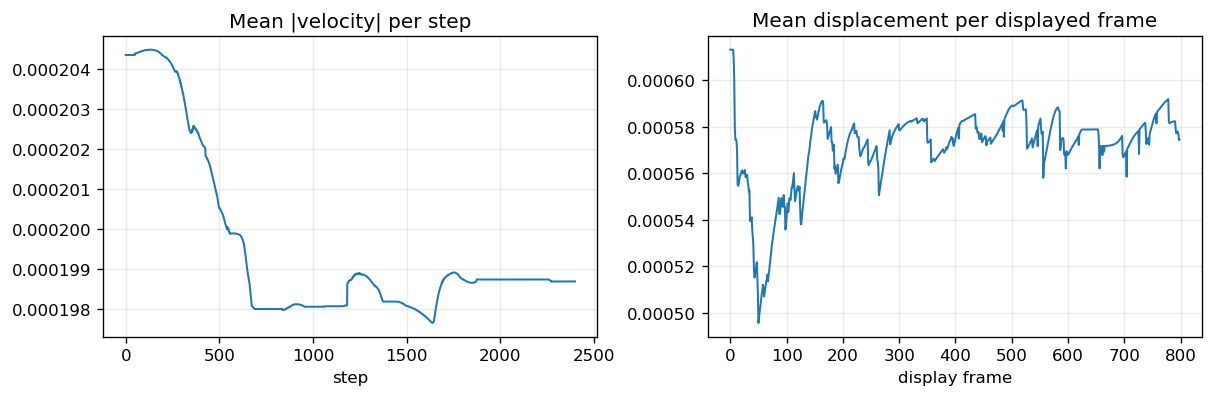

In [4]:
# More frequent snapshots for smooth playback and penetration diagnostics.
steps = 2400
every = 3
frames = []
speed_step = []
disp_per_frame = []
max_overlap = []
xx, vv = x.copy(), v.copy()
prev = None
for it in range(steps):
    xx, vv = step_particles(xx, vv, radius)
    speed_step.append(float(np.mean(np.abs(vv))))
    D = np.abs(xx[:, None] - xx[None, :])
    np.fill_diagonal(D, np.inf)
    max_overlap.append(float(max(0.0, 2 * radius - np.min(D))))
    if it % every == 0:
        cur = xx.copy()
        if prev is not None:
            disp_per_frame.append(float(np.mean(np.abs(cur - prev))))
        frames.append(cur)
        prev = cur

print("Stored frames:", len(frames))
print("Mean displacement per simulation step:", float(np.mean(speed_step)))
if disp_per_frame:
    print("Mean displacement per displayed frame:", float(np.mean(disp_per_frame)))
    print("Displayed-frame displacement p95:", float(np.quantile(disp_per_frame, 0.95)))
print("Max pair overlap over run:", float(np.max(max_overlap)))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), constrained_layout=True)
axes[0].plot(speed_step, lw=1.2)
axes[0].set_title("Mean |velocity| per step")
axes[0].set_xlabel("step")
axes[0].grid(alpha=0.25)
axes[1].plot(disp_per_frame, lw=1.2)
axes[1].set_title("Mean displacement per displayed frame")
axes[1].set_xlabel("display frame")
axes[1].grid(alpha=0.25)
plt.show()


## Rendering Model and Visual Design Choices

The rendering emphasizes trajectory readability:
- dark background for contrast,
- colored particles for identity tracking,
- light borders to preserve local separation in dense zones.

The display function is isolated so we can reuse the exact same renderer for:
1. interactive playback, and
2. static snapshot generation during automated notebook execution.

In [5]:
def show_frame(t=0):
    z = frames[t]
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_facecolor("#0f1221")
    centers = np.column_stack((np.real(z), np.imag(z)))
    patches = [Circle((cx, cy), radius=radius) for cx, cy in centers]
    coll = PatchCollection(patches, facecolor=colors, edgecolor="white", linewidth=0.35, alpha=0.96)
    ax.add_collection(coll)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.set_title(f"Particle system, frame {t}", color="#e8ebff")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_color("#d9ddff")
        spine.set_alpha(0.25)
    plt.show()


## Interactive Playback (Slider + Play/Stop)

This cell creates a frame slider and a Play widget linked by `jslink`, so animation can be explored continuously.

For automated evaluation, this UI cell is tagged `interactive` and can be skipped safely without affecting the physics or stored static outputs.

In [ ]:
# Interactive exploration with explicit play/stop control.
frame_slider = IntSlider(min=0, max=len(frames)-1, step=1, value=0, description="Frame")
play = Play(interval=70, value=0, min=0, max=len(frames)-1, step=1, description="Play")
jslink((play, "value"), (frame_slider, "value"))
out = interactive_output(show_frame, {"t": frame_slider})
display(HBox([play, frame_slider]), out)


## Static Snapshot for Reproducible Export (Optional)

In normal interactive use, this remains disabled to avoid duplicate figures.
Set `STATIC_SNAPSHOT = True` only when generating static exports.

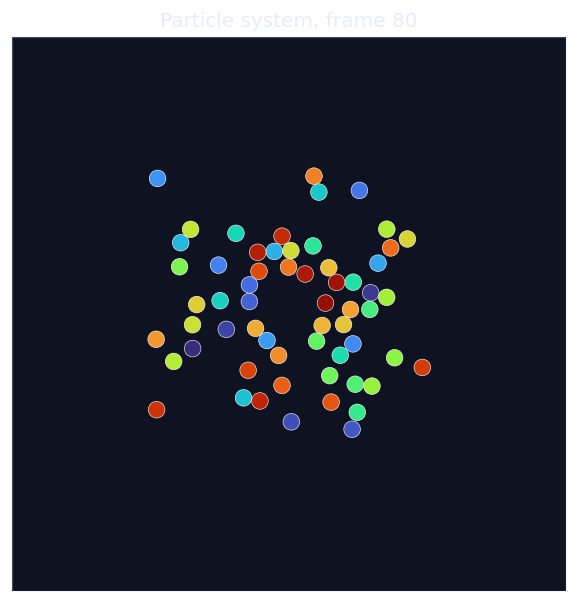

In [6]:
# Static representative render (optional for automated exports).
if STATIC_SNAPSHOT:
    show_frame(t=min(80, len(frames)-1))


## Bibliographical resources

- C. Cercignani, *The Boltzmann Equation and Its Applications*.
- L. E. Reichl, *A Modern Course in Statistical Physics*.
- D. Chandler, *Introduction to Modern Statistical Mechanics*.
